## **Logistic Regression: Perceptron Trick with Sigmoid**

### **Topic Roadmap**

**1. Dataset Generation**

**2. Classic Perceptron (Step Function)**

**3. Scikit-Learn Logistic Regression Baseline**

**4. The Perceptron Trick with Sigmoid**

**5. Decision Boundary Comparison**

### **1. Dataset Generation**

We start by generating a linearly separable binary classification dataset with a wide class separation.

In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


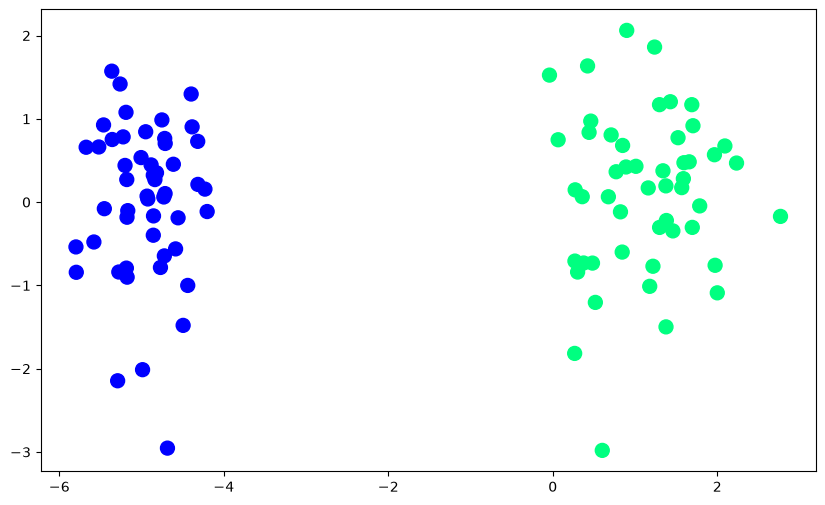

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Generate binary classification dataset with class_sep=30
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=30)

plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.show()

### **2. Classic Perceptron (Step Function)**

This establishes our baseline using a hard step function, which outputs either $1$ or $0$ based on whether the input $z$ is strictly greater than $0$.

In [2]:
def step(z):
    return 1 if z > 0 else 0

def perceptron_step(X, y):
    X_bias = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X_bias.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X_bias[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X_bias[j]
        
    return weights[0], weights[1:]

intercept_step, coef_step = perceptron_step(X, y)

# Calculate slope and intercept for the decision boundary line
m_step = -(coef_step[0] / coef_step[1])
b_step = -(intercept_step / coef_step[1])

x_input = np.linspace(-3, 3, 100)
y_input_step = m_step * x_input + b_step

### **3. Scikit-Learn Logistic Regression Baseline**

We train a standard Logistic Regression model to establish the ideal decision boundary for comparison.

In [3]:
lor = LogisticRegression()
lor.fit(X, y)

m_lor = -(lor.coef_[0][0] / lor.coef_[0][1])
b_lor = -(lor.intercept_ / lor.coef_[0][1])

y_input_lor = m_lor * x_input + b_lor

### **4. The Perceptron Trick with Sigmoid**

By replacing the hard step function with the continuous Sigmoid activation function, the model calculates probabilities rather than binary outputs during the weight update process.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def perceptron_sigmoid(X, y):
    X_bias = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X_bias.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = sigmoid(np.dot(X_bias[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X_bias[j]
        
    return weights[0], weights[1:]

intercept_sig, coef_sig = perceptron_sigmoid(X, y)

m_sig = -(coef_sig[0] / coef_sig[1])
b_sig = -(intercept_sig / coef_sig[1])

y_input_sig = m_sig * x_input + b_sig

### **5. Decision Boundary Comparison**

We plot the dataset along with the three calculated decision boundaries to visualize the difference in optimization.

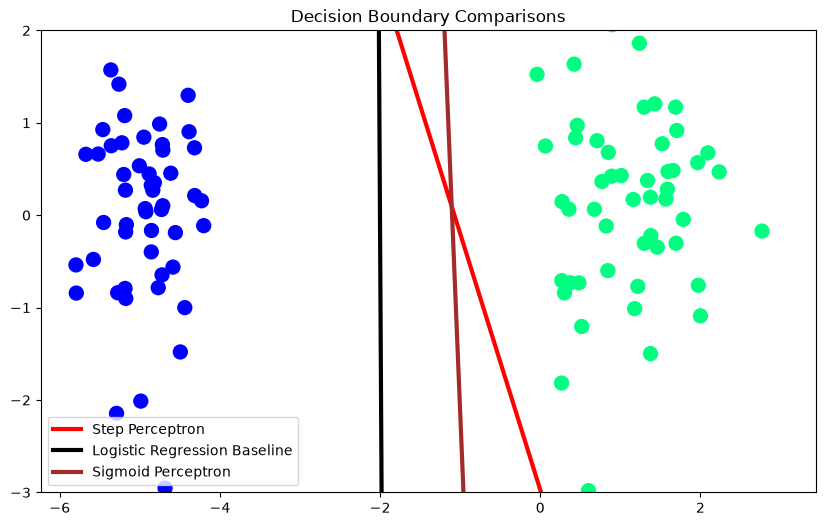

In [5]:
plt.figure(figsize=(10,6))

# Step Function Perceptron (Red)
plt.plot(x_input, y_input_step, color='red', linewidth=3, label='Step Perceptron')

# Scikit-Learn Logistic Regression (Black)
plt.plot(x_input, y_input_lor, color='black', linewidth=3, label='Logistic Regression Baseline')

# Sigmoid Perceptron (Brown)
plt.plot(x_input, y_input_sig, color='brown', linewidth=3, label='Sigmoid Perceptron')

plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.title('Decision Boundary Comparisons')
plt.show()

### **Key Revision Notes**

- **Activation Function Upgrade:** Replacing the step function with $1 / (1 + e^{-z})$ (the sigmoid function) transforms the Perceptron algorithm into a formulation highly similar to Logistic Regression.
- **Continuous Updates:** Because the sigmoid function outputs probabilities between $0$ and $1$, the error term `(y[j] - y_hat)` is never exactly $0$ unless the prediction is perfectly confident. This means the weights continuously update and refine the boundary, unlike the step function which stops updating as soon as the point is correctly classified on either side of the boundary.
- **Boundary Shift:** As seen in the plot, the brown line (Sigmoid Perceptron) aligns much closer to the optimal black line (Scikit-Learn Logistic Regression) than the red line (Step Perceptron).